# Multi-Agent Flood Exposure Screening Workflow

This notebook demonstrates a GAS workflow for screening flood exposure across two GAS servers. `gas_psu` points to the local server for GEE, vector/spatial analysis, and final web mapping app generation. `gas_gmu` points to `https://gas-dt.stcenter.net/` for the supporting retrieval, inspection, and static mapping agents.

**Example place:** Harris County, Texas.


## Install and Setup

In [ ]:
%pip install -q python-dotenv pandas requests

In [2]:
from pathlib import Path
import html
import json
import os
import sys

from dotenv import load_dotenv
from IPython.display import HTML, display

project_root = Path.cwd()
if project_root.name == "examples_for_using_gas_services":
    project_root = project_root.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from gas_client import GasClient

load_dotenv(project_root / ".env")

psu_server_url = os.getenv("GAS_PSU_SERVER_URL", os.getenv("GAS_SERVER_URL", "http://127.0.0.1:4042"))
gmu_server_url = os.getenv("GAS_GMU_SERVER_URL", "https://gas-dt.stcenter.net/")
openai_api_key = os.getenv("OPENAI_API_KEY")
gibd_api_key = os.getenv("GIBD_API_KEY")

if openai_api_key:
    model_credentials = {"OPENAI_API_KEY": openai_api_key}
elif gibd_api_key:
    model_credentials = {"GIBD_API_KEY": gibd_api_key}
else:
    raise RuntimeError("Set OPENAI_API_KEY or GIBD_API_KEY in the repo .env file before running this notebook.")

gas_psu = GasClient(psu_server_url, default_credentials=model_credentials, artifact_delivery="URL", timeout=1800)
gas_gmu = GasClient(gmu_server_url, default_credentials=model_credentials, artifact_delivery="URL", timeout=1800)

# Convenience alias for artifact parsing/display helpers. The task execution below routes through explicit agents.
client = gas_psu

agents = {
    # Local PSU server: Earth Engine, vector/spatial analysis, and final web app generation.
    "gee": gas_psu.agent("google_earth_engine_agent"),
    "vector": gas_psu.agent("vector_analysis_agent"),
    "spatial": gas_psu.agent("spatial_analysis_agent"),
    "web_app": gas_psu.agent("web_mapping_app_agent"),

    # GMU/STC server: remaining supporting agents used by this demo.
    "retrieval": gas_gmu.agent("geospatial_data_retrieval_agent"),
    "inspection": gas_gmu.agent("geospatial_data_inspection_agent"),
    "mapping": gas_gmu.agent("mapping_agent"),
}

psu_server_url, gmu_server_url, list(agents)


('http://127.0.0.1:4042',
 'https://gas-dt.stcenter.net/',
 ['gee', 'vector', 'spatial', 'web_app', 'retrieval', 'inspection', 'mapping'])

## Workflow Design

1. Retrieve county/city boundary and infrastructure layers from `gas_gmu`.
2. Inspect input datasets with `gas_gmu`.
3. Use the local `gas_psu` GEE agent for precipitation extremes, surface-water occurrence or recent flood-water screening, and land-cover context.
4. Use local `gas_psu` vector/spatial agents to prepare infrastructure exposure summaries where suitable layers exist.
5. Use `gas_gmu` mapping for a static briefing figure.
6. Use the local `gas_psu` web mapping app agent to create the professional final web app product.

The flood-hazard screen combines precipitation context with the GEE agent's surface-water skill. JRC Global Surface Water gives long-term water occurrence, while Sentinel-1 can be requested for recent radar-based flood-water screening.


## Step 1: Retrieve Boundary and Infrastructure Inputs

In [3]:
county_result = gas_gmu.run_streaming_task(
    agents["retrieval"],
    "Retrieve the county boundary for Harris County, Texas as WGS84 GeoJSON or GeoPackage. Return only the county boundary polygon.",
)

[23:46:35] stream_connected: Streaming connection established.
[23:46:36] Geospatial Data Retrieval Agent: I received your request.
[23:46:36] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[23:46:36] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[23:46:36] task_accepted: Task accepted. Starting streaming execution.
[23:46:36] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[23:46:36] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[23:46:38] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[23:46:38] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[23:46:38] Geospatial Data Retrieval Agent: I am comparing

Artifacts: 1
1. geospatial_data_retrieval_agent-0207-jutc-7735.gpkg
   format           : gpkg
   type             : downloadable_file
   name             : geospatial_data_retrieval_agent-0207-jutc-7735.gpkg
   size_bytes       : 114688
   url              : https://gas-dt.stcenter.net/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-0207-jutc-7735.gpkg


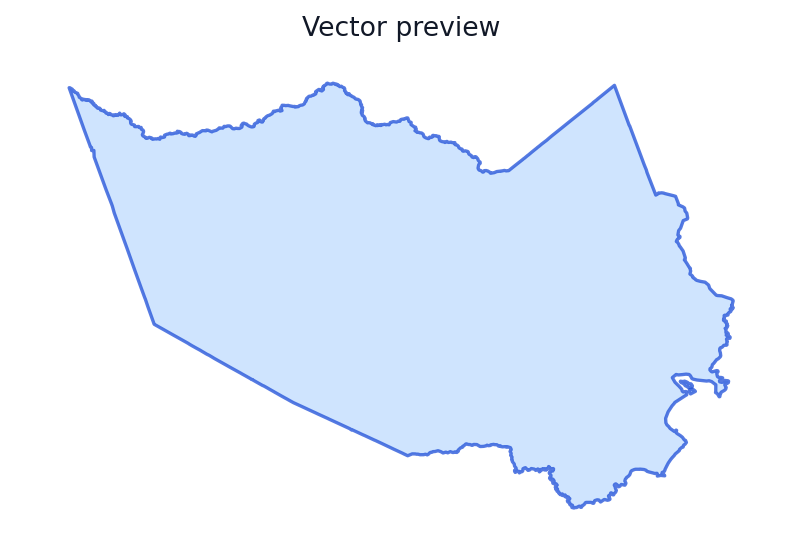

STATEFP,COUNTYFP,COUNTYNS,AFFGEOID,GEOID,NAME,NAMELSAD,STUSPS,STATE_NAME,LSAD,ALAND,AWATER
48,201,01383886,0500000US48201,48201,Harris,Harris County,TX,Texas,06,4421068052,182379558


In [4]:
county_boundary_url = client.get_artifact_urls(county_result)[0]
client.print_artifacts(county_result)
client.display_artifacts(county_result, height=300)


In [7]:
roads_result = gas_gmu.run_streaming_task(
    agents["retrieval"],
    "Retrieve major road centerlines for Harris County, Texas. Return GeoJSON with road name/type attributes.",
)


[23:54:23] stream_connected: Streaming connection established.
[23:54:23] Geospatial Data Retrieval Agent: I received your request.
[23:54:23] Geospatial Data Retrieval Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 0 dataset reference(s).
[23:54:23] Geospatial Data Retrieval Agent: I found the required credentials and can start the model-backed workflow.
[23:54:23] task_accepted: Task accepted. Starting streaming execution.
[23:54:24] Geospatial Data Retrieval Agent: Next I will run the agent with the prepared inputs.
[23:54:24] Geospatial Data Retrieval Agent: I am checking whether the request asks for one dataset or several.
[23:54:25] Geospatial Data Retrieval Agent: The request was decomposed into 1 sub-request(s).
[23:54:25] Geospatial Data Retrieval Agent: I will identify the most suitable supported data source, then generate source-specific download logic.
[23:54:25] Geospatial Data Retrieval Agent: I am comparing

Artifacts: 1
1. geospatial_data_retrieval_agent-6429-bcyu-8361.geojson
   format           : geojson
   type             : downloadable_file
   name             : geospatial_data_retrieval_agent-6429-bcyu-8361.geojson
   size_bytes       : 19199236
   url              : https://gas-dt.stcenter.net/agents/geospatial_data_retrieval_agent/data/geospatial_data_retrieval_agent-6429-bcyu-8361.geojson


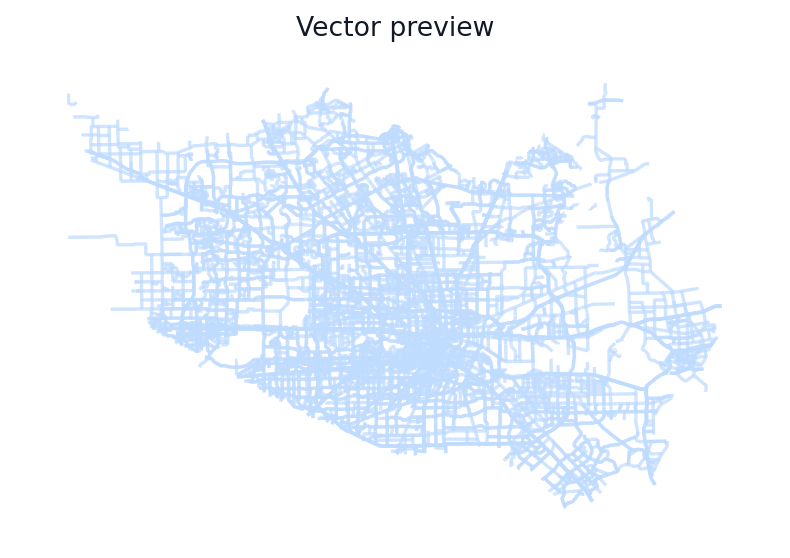

id,highway,name
15276281,tertiary,Border Street
15276451,tertiary,Windystone Drive
15276601,secondary,East Richey Road
15276939,secondary,Tidwell Road
15276965,tertiary,Airline Drive


In [8]:
roads_url = client.get_artifact_urls(roads_result)[0]
client.print_artifacts(roads_result)
client.display_artifacts(roads_result, height=300)


## Step 2: Inspect Boundary and Infrastructure Data

In [9]:
input_inspection_result = gas_gmu.run_streaming_task(
    agents["inspection"],
    "Inspect the county boundary and roads datasets for CRS, geometry validity, columns, and readiness for flood exposure screening.",
    input_datasets=[county_boundary_url, roads_url],
)
client.print_artifacts(input_inspection_result)

[23:57:14] stream_connected: Streaming connection established.
[23:57:14] Geospatial Data Inspection Agent: I received your request.
[23:57:14] Geospatial Data Inspection Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[23:57:14] Geospatial Data Inspection Agent: I found the required credentials and can start the model-backed workflow.
[23:57:14] task_accepted: Task accepted. Starting streaming execution.
[23:57:15] Geospatial Data Inspection Agent: Next I will run the agent with the prepared inputs.
[23:57:15] Geospatial Data Inspection Agent: I will inspect the supplied datasets for geospatial quality, validation issues, and workflow readiness.
[23:57:15] Geospatial Data Inspection Agent: I am classifying each input as vector, raster, table, or unsupported before running type-specific checks.
[23:57:15] Geospatial Data Inspection Agent: Inspecting dataset 1 of 2: geospatial_data_retrieval_agent-02

In [10]:
client.display_artifacts(input_inspection_result,format="html")

## Step 3: GEE Precipitation Context

In [11]:
precip_result = gas_psu.run_streaming_task(
    agents["gee"],
    "Using the uploaded Harris County boundary as the analysis region, create a daily precipitation time series for April 1 to September 30, 2024. Return a CSV table and an HTML line chart.",
    input_datasets=[county_boundary_url],
    parameters={"variables": ["precipitation"], "scale": 5000},
)


[23:58:19] stream_connected: Streaming connection established.
[23:58:20] Google Earth Engine Agent: I received your request.
[23:58:20] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[23:58:20] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[23:58:20] task_accepted: Task accepted. Starting streaming execution.
[23:58:21] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[23:58:21] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[23:58:25] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[23:58:27] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[23:58:27] Google Earth Engine Agent: I am executing the va

In [12]:
client.print_artifacts(precip_result)
client.display_artifacts(precip_result)

Artifacts: 2
1. Climate Time Series Csv
   role             : climate_time_series_csv_file
   format           : csv
   type             : downloadable_file
   name             : google_earth_engine_agent-6160-kyav-0812.csv
   original_filename: gee_climate_time_series_using_the_uploaded_harris_county_581824.csv
   size_bytes       : 4889
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-6160-kyav-0812.csv
2. Climate Time Series Html
   role             : climate_time_series_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-1282-yxfy-5323.html
   original_filename: gee_climate_time_series_using_the_uploaded_harris_county_431803.html
   size_bytes       : 6708
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-1282-yxfy-5323.html


date,precipitation
2024-04-01,0.38897940410221754
2024-04-02,0.09705181661499514
2024-04-03,0.0
2024-04-04,0.0
2024-04-05,0.0


## Step 4: Land-Cover / Impervious Context

In [13]:
land_cover_result = gas_psu.run_streaming_task(
    agents["gee"],
    "Using the uploaded Harris County boundary, summarize ESA WorldCover class area. Return a CSV table with class id, class name, and area in square kilometers.",
    input_datasets=[county_boundary_url],
    parameters={"scale": 30},
)


[23:59:14] stream_connected: Streaming connection established.
[23:59:15] Google Earth Engine Agent: I received your request.
[23:59:15] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[23:59:15] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[23:59:15] task_accepted: Task accepted. Starting streaming execution.
[23:59:15] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[23:59:15] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[23:59:20] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[23:59:20] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[23:59:20] Google Earth Engine Agent: I am executing the va

In [14]:
client.print_artifacts(land_cover_result)
client.display_artifacts(land_cover_result)

Artifacts: 1
1. Land Cover Area Summary Csv
   role             : land_cover_area_summary_csv_file
   format           : csv
   type             : downloadable_file
   name             : google_earth_engine_agent-1895-eunt-3187.csv
   original_filename: gee_land_cover_area_summary_using_the_uploaded_harris_county_429594.csv
   size_bytes       : 325
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-1895-eunt-3187.csv


area_sq_km,class_id,class_name
1902.7636483045678,10,Tree cover
0.004676640625,20,Shrubland
982.2828547834396,30,Grassland
110.65797306342193,40,Cropland
1311.8645131968374,50,Built-up


In [15]:
land_cover_map_result = gas_psu.run_streaming_task(
    agents["gee"],
    "Using the uploaded Harris County boundary, create an ESA WorldCover land-cover map. Return an interactive HTML map with the class-color legend.",
    input_datasets=[county_boundary_url],
    parameters={"scale": 30},
)


[23:59:30] stream_connected: Streaming connection established.
[23:59:30] Google Earth Engine Agent: I received your request.
[23:59:31] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[23:59:31] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[23:59:31] task_accepted: Task accepted. Starting streaming execution.
[23:59:31] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[23:59:31] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[23:59:35] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[23:59:35] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[23:59:35] Google Earth Engine Agent: I am executing the va

In [16]:
client.print_artifacts(land_cover_map_result)
client.display_artifacts(land_cover_map_result)

Artifacts: 1
1. Land Cover Interactive Map Html
   role             : land_cover_interactive_map_html_file
   format           : html
   type             : downloadable_file
   name             : google_earth_engine_agent-5598-lhvm-4318.html
   original_filename: gee_land_cover_map_using_the_uploaded_harris_county_542954.html
   size_bytes       : 38212
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-5598-lhvm-4318.html


## Step 5: GEE Surface Water / Flood Water Screening

This step uses the new GEE `create_surface_water_map` workflow. The request below asks for JRC Global Surface Water occurrence because it is stable for exposure screening and produces an HTML map plus CSV/GeoJSON outputs. For a recent event, change the request text to Sentinel-1 and provide an event date range; an example is included in the next cell.

[00:00:21] stream_connected: Streaming connection established.
[00:00:21] Google Earth Engine Agent: I received your request.
[00:00:21] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[00:00:21] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[00:00:22] task_accepted: Task accepted. Starting streaming execution.
[00:00:22] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[00:00:22] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[00:00:27] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[00:00:28] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[00:00:28] Google Earth Engine Agent: I am executing the va

dataset,dataset_id,date_end,date_start,region_name,scale_m,water_area_sq_km,water_definition
jrc_global_surface_water,JRC/GSW1_4/GlobalSurfaceWater,,,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,30,115.86733711471838,JRC occurrence >= 50.0 percent


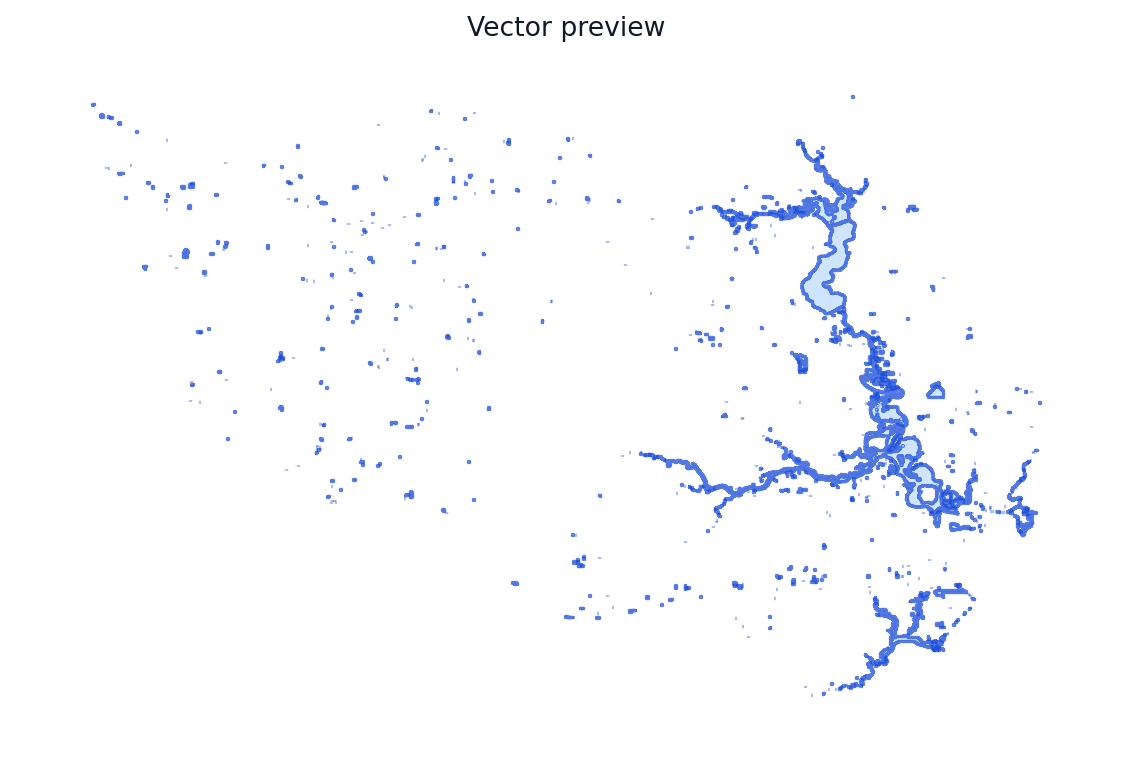

id,count,water_mask,region_name,dataset,water_class
+311905+199846,16,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,jrc_global_surface_water,mapped_surface_water
+311945+199893,88,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,jrc_global_surface_water,mapped_surface_water
+311960+200101,5,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,jrc_global_surface_water,mapped_surface_water
+311968+200102,5,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,jrc_global_surface_water,mapped_surface_water
+311970+199894,4,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,jrc_global_surface_water,mapped_surface_water


In [17]:
water_result = gas_psu.run_streaming_task(
    agents["gee"],
    "Using the uploaded Harris County boundary as the analysis region, map surface water occurrence using JRC Global Surface Water. Return an HTML map plus GeoJSON and CSV exposure-ready outputs with mapped water area.",
    input_datasets=[county_boundary_url],
    parameters={"scale": 30, "water_occurrence_threshold": 50},
)
client.print_artifacts(water_result)
client.display_artifacts(water_result)


In [23]:
#Optional recent flood-water/SAR variant. Adjust dates for a specific flood event.
sentinel1_water_result = gas_psu.run_streaming_task(
    agents["gee"],
    "Using the uploaded Harris County boundary as the analysis region, map recent flood water using Sentinel-1 VV SAR from August 1 to August 30, 2017. Return an HTML map plus GeoJSON and CSV exposure-ready outputs.",
    input_datasets=[county_boundary_url],
    parameters={"scale": 60, "sentinel1_water_threshold_db": -17},
)


[00:07:10] stream_connected: Streaming connection established.
[00:07:10] Google Earth Engine Agent: I received your request.
[00:07:10] Google Earth Engine Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 1 dataset reference(s).
[00:07:10] Google Earth Engine Agent: I found the required credentials and can start the model-backed workflow.
[00:07:11] task_accepted: Task accepted. Starting streaming execution.
[00:07:11] Google Earth Engine Agent: Next I will start the workflow with the prepared inputs.
[00:07:11] Google Earth Engine Agent: I am asking the LLM for a constrained Earth Engine workflow plan.
[00:07:15] Google Earth Engine Agent: I validated the requested Earth Engine action, dataset, date range, region, and outputs.
[00:07:16] Google Earth Engine Agent: Initialized Earth Engine with project geospatialagenticservice using the deployment service account.
[00:07:16] Google Earth Engine Agent: I am executing the va

Artifacts: 3
1. Surface Water Summary Csv
   role             : surface_water_summary_csv_file
   format           : csv
   type             : downloadable_file
   name             : google_earth_engine_agent-0384-unpp-4023.csv
   original_filename: gee_surface_water_summary_using_the_uploaded_harris_county_908267.csv
   size_bytes       : 249
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-0384-unpp-4023.csv
2. Surface Water Polygons Geojson
   role             : surface_water_polygons_geojson_file
   format           : geojson
   type             : downloadable_file
   name             : google_earth_engine_agent-3335-gbtc-6523.geojson
   original_filename: gee_surface_water_polygons_using_the_uploaded_harris_county_305654.geojson
   size_bytes       : 3564271
   url              : http://127.0.0.1:4042/agents/google_earth_engine_agent/data/google_earth_engine_agent-3335-gbtc-6523.geojson
3. Surface Water Interactive Map Htm

dataset,dataset_id,date_end,date_start,region_name,scale_m,water_area_sq_km,water_definition
sentinel1_grd,COPERNICUS/S1_GRD,2017-08-30,2017-08-01,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,60,115.07727931222331,VV backscatter < -17.0 dB


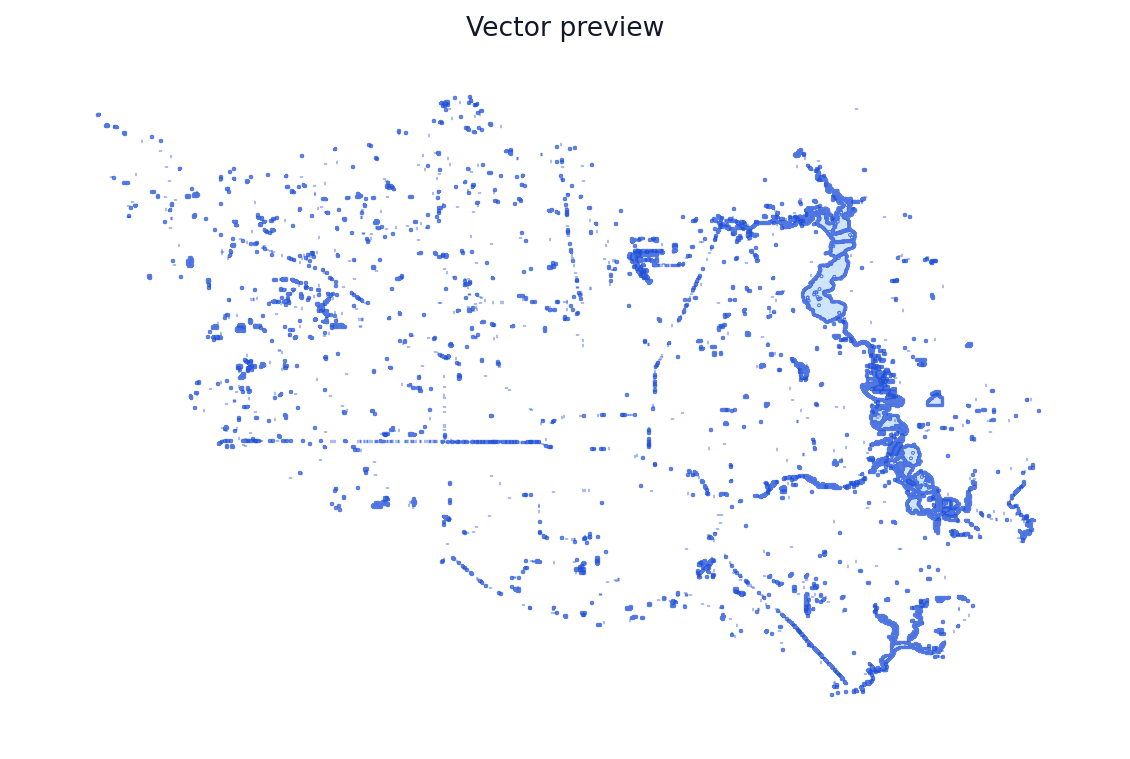

id,count,water_mask,region_name,dataset,water_class
-176094+55323,5,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,sentinel1_grd,mapped_surface_water
-176105+55093,1,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,sentinel1_grd,mapped_surface_water
-176106+55206,1,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,sentinel1_grd,mapped_surface_water
-176106+55212,1,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,sentinel1_grd,mapped_surface_water
-176107+55101,5,1,geospatial_data_retrieval_agent-0207-jutc-7735.gpkg,sentinel1_grd,mapped_surface_water


In [24]:
client.print_artifacts(sentinel1_water_result)
client.display_artifacts(sentinel1_water_result)

## Step 6: Vector Exposure Screening with Available Inputs

In [25]:
roads_clip_result = gas_psu.run_streaming_task(
    agents["vector"],
    "Clip the roads dataset to the Harris County boundary and calculate road length by road type/name if the fields are available. Return a CSV summary and a GeoPackage or GeoJSON clipped roads layer.",
    input_datasets=[roads_url, county_boundary_url],
)


[00:08:22] stream_connected: Streaming connection established.
[00:08:24] Vector Analysis Agent: I received your request.
[00:08:24] Vector Analysis Agent: I need to inspect the request text and any provided dataset references before running the agent. I found 2 dataset reference(s).
[00:08:24] Vector Analysis Agent: I found the required credentials and can start the model-backed workflow.
[00:08:24] task_accepted: Task accepted. Starting streaming execution.
[00:08:25] Vector Analysis Agent: Next I will start the workflow with the prepared inputs.
[00:08:25] Vector Analysis Agent: I will load the requested vector/tabular inputs, run code-driven analysis, and save a final dataset artifact from 2 dataset reference(s).
[00:08:25] Vector Analysis Agent: I detected a common vector operation and will first try a deterministic GeoPandas workflow.
[00:08:27] Vector Analysis Agent: Added geometry measurement field(s): length_m, length_km and saved 57472 feature(s) as GeoPackage.
[00:08:27] Vec

Artifacts: 1
1. Dataset
   role             : dataset_path
   format           : gpkg
   type             : downloadable_file
   name             : vector_analysis_agent-6984-zyor-8036.gpkg
   original_filename: clip_the_955079.gpkg
   size_bytes       : 15474688
   url              : http://127.0.0.1:4042/agents/vector_analysis_agent/data/vector_analysis_agent-6984-zyor-8036.gpkg


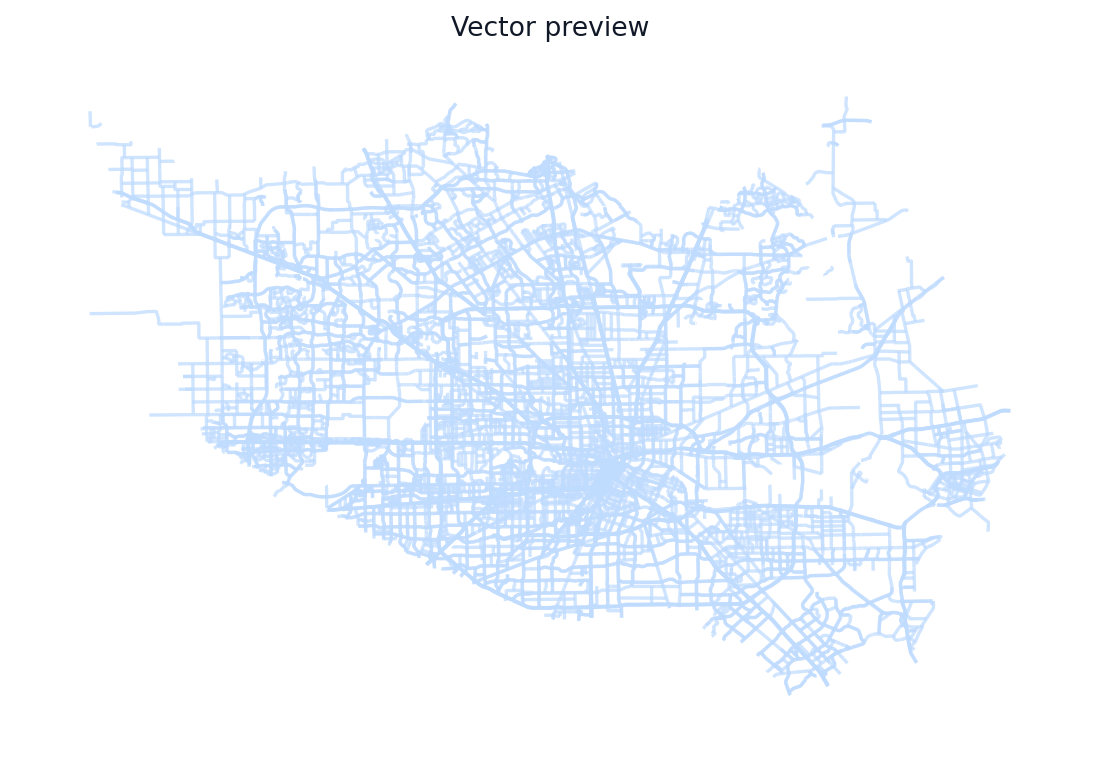

id,highway,name,length_m,length_km
15276281,tertiary,Border Street,210.64240091187432,0.2106424009118743
15276451,tertiary,Windystone Drive,1577.6604179637147,1.5776604179637148
15276601,secondary,East Richey Road,368.2152981946546,0.3682152981946546
15276939,secondary,Tidwell Road,38.629413925177005,0.038629413925177006
15276965,tertiary,Airline Drive,50.37997646059496,0.05037997646059496


In [26]:
client.print_artifacts(roads_clip_result)
client.display_artifacts(roads_clip_result)

## Step 7: Final Flood Screening Briefing Figure

In [40]:
precip_csv_url = client.get_artifact_urls(precip_result, format="csv")[0]
land_cover_csv_url = client.get_artifact_urls(land_cover_result, format="csv")[0]
water_geojson_url = client.get_artifact_urls(water_result, format="geojson")[0]
roads_url = client.get_artifact_urls(roads_clip_result)[0]

flood_figure_result = agents["mapping"].execute_task(
    (
        "Create a light-mode flood exposure screening briefing figure for Harris County. "
        "Use the precipitation CSV, land-cover CSV, mapped water GeoJSON, and clipped roads layer. "
        "Show precipitation, mapped water context, land-cover context, and road exposure context. "
        "Ensure labels and panels do not overlap. Return a PNG."
    ),
    mode="sync",
    input_datasets=[
        precip_csv_url,
        land_cover_csv_url,
        water_geojson_url,
        roads_url,
    ],
    parameters={
        "renderer": "llm",
        "max_iterations": 3,
    },
)



GasClientError: GAS request failed with HTTP 500: <!doctype html>
<html lang=en>
<title>500 Internal Server Error</title>
<h1>Internal Server Error</h1>
<p>The server encountered an internal error and was unable to complete your request. Either the server is overloaded or there is an error in the application.</p>


In [ ]:
client.print_artifacts(flood_figure_result)
client.display_artifacts(flood_figure_result)

## Step 8: Final Product Web Mapping App

This final step uses the local PSU `web_mapping_app_agent` to turn the workflow outputs into a professional browser-ready web app. The app should include the Harris County boundary, road/infrastructure layer, mapped surface-water polygons, and dashboard/sidebar context from precipitation and land-cover summaries.

In [ ]:
web_app_inputs = [
    county_boundary_url,
    roads_url,
    water_geojson_url,
    water_csv_url,
    land_cover_csv_url,
    precip_csv_url,
    roads_summary_url,
]

web_app_result = gas_psu.run_streaming_task(
    agents["web_app"],
    "Create a professional flood exposure screening web mapping app for Harris County, Texas. Build a polished light-mode Leaflet/Folium-style HTML application with a clear title, layer control, compact legends, and sidebar summary. Map the county boundary, primary roads or clipped road exposure layer, and mapped surface-water occurrence polygons. Use the precipitation CSV, land-cover CSV, water exposure CSV, and roads summary to populate concise dashboard cards or tables. Include popups for vector layers, distinguish mapped water and infrastructure layers with professional symbology, and make the app suitable as the final product of the demo.",
    input_datasets=web_app_inputs,
    parameters={"requested_skill": "web_mapping_app_development"},
)
client.print_artifacts(web_app_result)
client.display_artifacts(web_app_result, format="html", height=720)
